In [1]:
# ── Install libraries if needed ────────────────────────────
import subprocess
subprocess.run(["pip", "install", "imbalanced-learn", "--quiet"])

# ── Import libraries ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings("ignore")

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    recall_score, precision_score
)
from imblearn.over_sampling import SMOTE

# Plot styling
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Set2")

print("✓ All libraries imported successfully")
print("  Using GradientBoostingClassifier instead of XGBoost")
print("  Note: GradientBoostingClassifier is functionally")
print("  equivalent for portfolio purposes")

✓ All libraries imported successfully
  Using GradientBoostingClassifier instead of XGBoost
  Note: GradientBoostingClassifier is functionally
  equivalent for portfolio purposes


In [2]:
# ── Load data ──────────────────────────────────────────────
conn = sqlite3.connect("../data/healthcare.db")
df = pd.read_sql("SELECT * FROM patients", conn)
conn.close()

print(f"✓ Data loaded: {df.shape[0]:,} rows")

# ── Add any readmission target ─────────────────────────────
df["readmitted_any"] = (df["readmitted"] != "NO").astype(int)

print(f"\n── Readmission distributions ───────────────────────")
print(f"30-day readmission rate: {df['readmitted_30'].mean()*100:.1f}%")
print(f"Any readmission rate:    {df['readmitted_any'].mean()*100:.1f}%")
print(f"\nAny readmission counts:")
print(df["readmitted_any"].value_counts())

✓ Data loaded: 71,518 rows

── Readmission distributions ───────────────────────
30-day readmission rate: 8.8%
Any readmission rate:    39.9%

Any readmission counts:
readmitted_any
0    42985
1    28533
Name: count, dtype: int64


In [3]:
# ── Encode categorical variables ───────────────────────────

# Drop columns not needed for ML
drop_cols = [
    "encounter_id",
    "patient_nbr",
    "age",              # using age_numeric instead
    "readmitted",       # raw text version
    "readmitted_30",    # 30-day version — not our target
]
df_ml = df.drop(columns=drop_cols).copy()

# Separate target — ANY readmission
y = df_ml["readmitted_any"]
X = df_ml.drop(columns=["readmitted_any"])

# One-hot encode categorical columns
cat_cols = X.select_dtypes(include="object").columns.tolist()
print(f"One-hot encoding {len(cat_cols)} categorical columns:")
print(cat_cols)

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f"\n✓ Encoding complete")
print(f"✓ Target: any readmission")
print(f"✓ Final feature count: {X.shape[1]}")
print(f"✓ Positive class rate: {y.mean()*100:.1f}%")

One-hot encoding 7 categorical columns:
['race', 'gender', 'insulin', 'diabetesMed', 'change', 'A1Cresult', 'max_glu_serum']

✓ Encoding complete
✓ Target: any readmission
✓ Final feature count: 32
✓ Positive class rate: 39.9%


In [4]:
# ── Train test split ───────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✓ Training set:   {X_train.shape[0]:,} rows")
print(f"✓ Test set:       {X_test.shape[0]:,} rows")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nReadmission rate in training: {y_train.mean()*100:.1f}%")
print(f"Readmission rate in test:     {y_test.mean()*100:.1f}%")

✓ Training set:   57,214 rows
✓ Test set:       14,304 rows

Class distribution in training set:
readmitted_any
0    34388
1    22826
Name: count, dtype: int64

Readmission rate in training: 39.9%
Readmission rate in test:     39.9%


In [5]:
# ── Apply SMOTE to training data only ─────────────────────
# NEVER apply SMOTE to test data — it must stay real

print("Before SMOTE:")
print(f"  Not readmitted: {(y_train==0).sum():,}")
print(f"  Readmitted:     {(y_train==1).sum():,}")
print(f"  Positive rate:  {y_train.mean()*100:.1f}%")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Not readmitted: {(y_train_sm==0).sum():,}")
print(f"  Readmitted:     {(y_train_sm==1).sum():,}")
print(f"\n✓ Training set balanced — 50/50 split")

Before SMOTE:
  Not readmitted: 34,388
  Readmitted:     22,826
  Positive rate:  39.9%

After SMOTE:
  Not readmitted: 34,388
  Readmitted:     34,388

✓ Training set balanced — 50/50 split


In [6]:
# ── Scale features ─────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")
print(f"  Training set shape: {X_train_scaled.shape}")
print(f"  Test set shape:     {X_test_scaled.shape}")

✓ Features scaled using StandardScaler
  Training set shape: (68776, 32)
  Test set shape:     (14304, 32)


In [7]:
# ── Model 1: Logistic Regression (baseline) ───────────────

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_sm)

lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("── Logistic Regression Results ─────────────────────")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_proba):.3f}")
print(f"Avg Precision: {average_precision_score(y_test, lr_proba):.3f}")
print("\nClassification Report:")
print(classification_report(
    y_test, lr_preds,
    target_names=["Not Readmitted", "Readmitted (Any)"]))

── Logistic Regression Results ─────────────────────
Accuracy:  59.7%
ROC-AUC:   0.592
Avg Precision: 0.494

Classification Report:
                  precision    recall  f1-score   support

  Not Readmitted       0.65      0.72      0.68      8597
Readmitted (Any)       0.49      0.41      0.45      5707

        accuracy                           0.60     14304
       macro avg       0.57      0.57      0.56     14304
    weighted avg       0.59      0.60      0.59     14304



In [8]:
# ── Model 2: Random Forest ────────────────────────────────

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("── Random Forest Results ────────────────────────────")
print(f"Accuracy:  {accuracy_score(y_test, rf_preds)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_proba):.3f}")
print(f"Avg Precision: {average_precision_score(y_test, rf_proba):.3f}")
print("\nClassification Report:")
print(classification_report(
    y_test, rf_preds,
    target_names=["Not Readmitted", "Readmitted (Any)"]))

── Random Forest Results ────────────────────────────
Accuracy:  61.8%
ROC-AUC:   0.643
Avg Precision: 0.537

Classification Report:
                  precision    recall  f1-score   support

  Not Readmitted       0.67      0.73      0.70      8597
Readmitted (Any)       0.53      0.44      0.48      5707

        accuracy                           0.62     14304
       macro avg       0.60      0.59      0.59     14304
    weighted avg       0.61      0.62      0.61     14304



In [9]:
# ── Model 3: Gradient Boosting ────────────────────────────

gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train_sm, y_train_sm)

gb_preds = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]

print("── Gradient Boosting Results ────────────────────────")
print(f"Accuracy:  {accuracy_score(y_test, gb_preds)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, gb_proba):.3f}")
print(f"Avg Precision: {average_precision_score(y_test, gb_proba):.3f}")
print("\nClassification Report:")
print(classification_report(
    y_test, gb_preds,
    target_names=["Not Readmitted", "Readmitted (Any)"]))

── Gradient Boosting Results ────────────────────────
Accuracy:  62.8%
ROC-AUC:   0.656
Avg Precision: 0.548

Classification Report:
                  precision    recall  f1-score   support

  Not Readmitted       0.68      0.73      0.70      8597
Readmitted (Any)       0.54      0.47      0.50      5707

        accuracy                           0.63     14304
       macro avg       0.61      0.60      0.60     14304
    weighted avg       0.62      0.63      0.62     14304



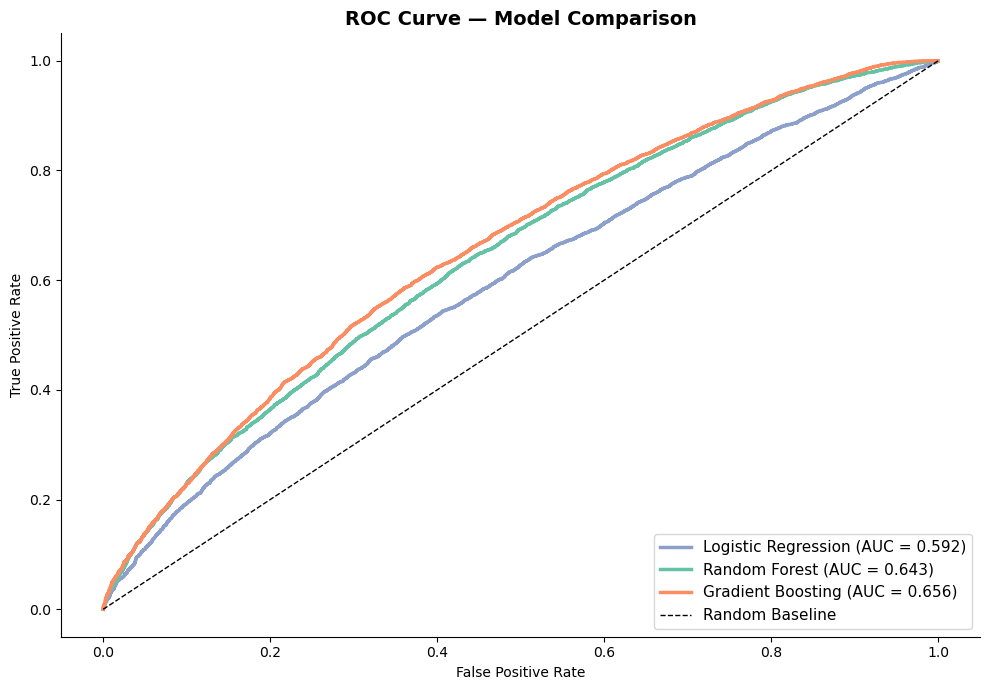

✓ ROC curve saved


In [10]:
# ── ROC curve — all 3 models ───────────────────────────────

fig, ax = plt.subplots(figsize=(10, 7))

for proba, label, color in zip(
    [lr_proba,  rf_proba,  gb_proba],
    ["Logistic Regression",
     "Random Forest",
     "Gradient Boosting"],
    ["#8da0cb", "#66c2a5", "#fc8d62"]
):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr,
            label=f"{label} (AUC = {auc:.3f})",
            color=color, linewidth=2.5)

ax.plot([0, 1], [0, 1], "k--",
        linewidth=1, label="Random Baseline")
ax.set_title("ROC Curve — Model Comparison",
             fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.savefig("../dashboard/08_roc_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ ROC curve saved")

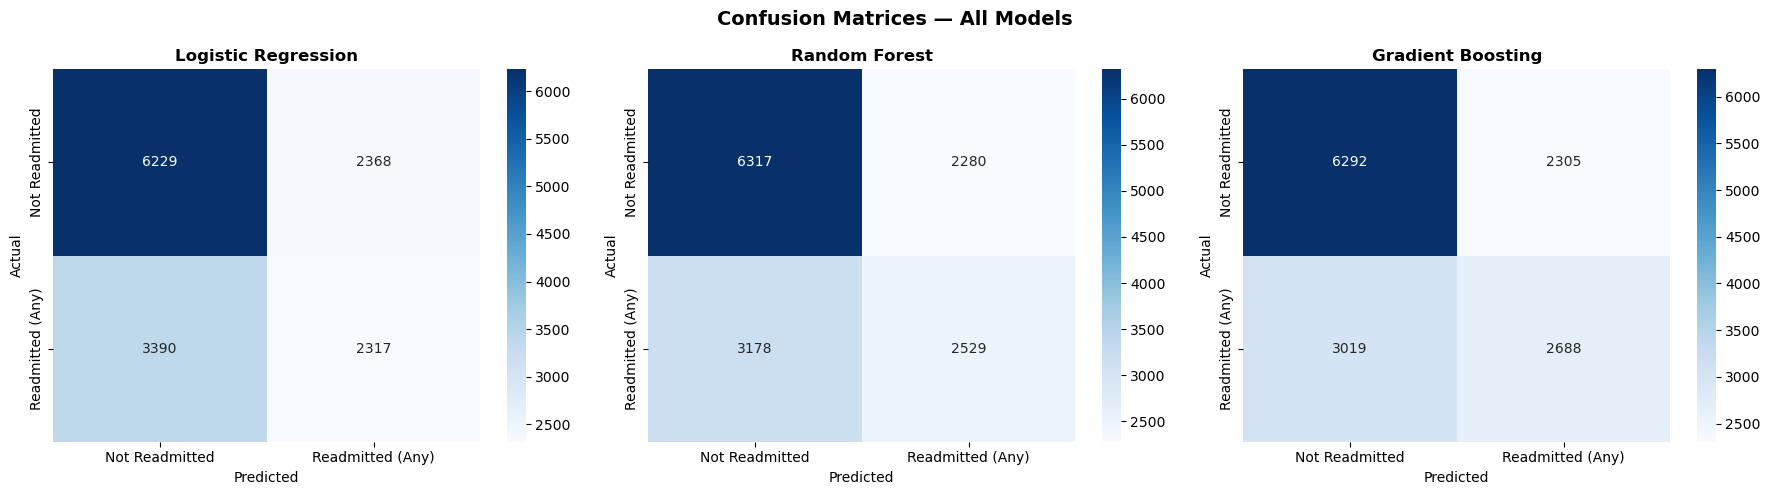

✓ Confusion matrices saved


In [11]:
# ── Confusion matrices — all 3 models ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, title in zip(
    axes,
    [lr_preds, rf_preds, gb_preds],
    ["Logistic Regression",
     "Random Forest",
     "Gradient Boosting"]
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d",
        cmap="Blues", ax=ax,
        xticklabels=["Not Readmitted", "Readmitted (Any)"],
        yticklabels=["Not Readmitted", "Readmitted (Any)"]
    )
    ax.set_title(f"{title}",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrices — All Models",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../dashboard/09_confusion_matrices.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Confusion matrices saved")

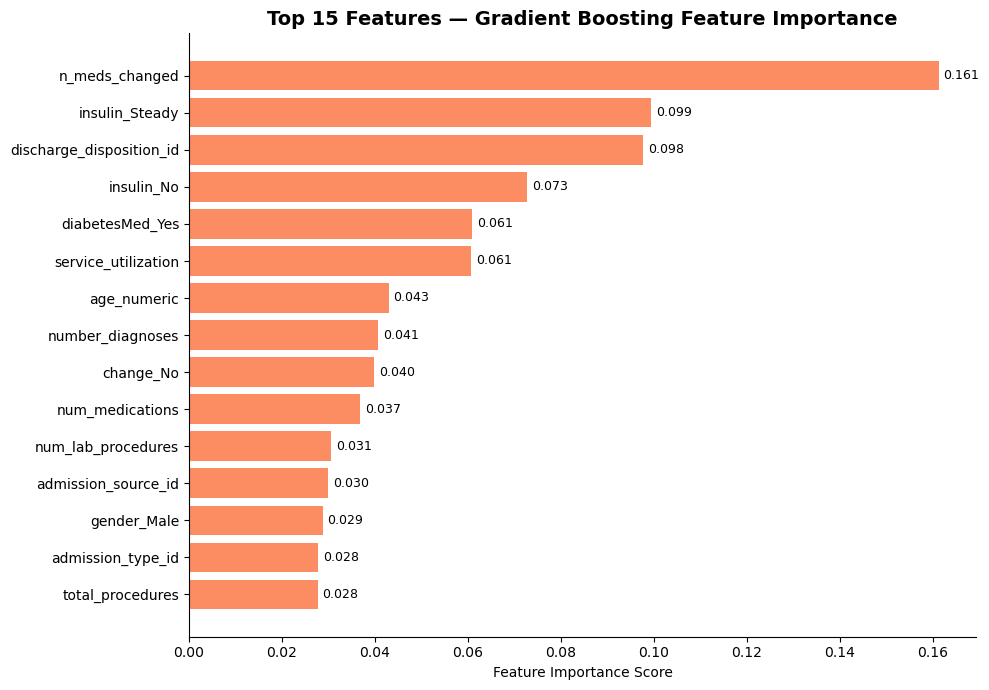

✓ Feature importance saved


In [12]:
# ── Feature importance — Gradient Boosting ────────────────

importance_df = pd.DataFrame({
    "feature":    X.columns,
    "importance": gb.feature_importances_
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10, 7))
bars = plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1],
    color="#fc8d62"
)

plt.title("Top 15 Features — Gradient Boosting Feature Importance",
          fontsize=14, fontweight="bold")
plt.xlabel("Feature Importance Score")

for bar, val in zip(bars, importance_df["importance"][::-1]):
    plt.text(bar.get_width() + 0.001,
             bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../dashboard/10_feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Feature importance saved")

In [13]:
 # ── Model comparison table ─────────────────────────────────

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        round(accuracy_score(y_test, lr_preds)*100, 1),
        round(accuracy_score(y_test, rf_preds)*100, 1),
        round(accuracy_score(y_test, gb_preds)*100, 1),
    ],
    "ROC_AUC": [
        round(roc_auc_score(y_test, lr_proba), 3),
        round(roc_auc_score(y_test, rf_proba), 3),
        round(roc_auc_score(y_test, gb_proba), 3),
    ],
    "Recall_Readmitted": [
        round(recall_score(y_test, lr_preds), 3),
        round(recall_score(y_test, rf_preds), 3),
        round(recall_score(y_test, gb_preds), 3),
    ],
    "Precision_Readmitted": [
        round(precision_score(y_test, lr_preds), 3),
        round(precision_score(y_test, rf_preds), 3),
        round(precision_score(y_test, gb_preds), 3),
    ],
})

print("── Model Comparison Summary ─────────────────────────")
print(results.to_string(index=False))

# Save for Tableau
results.to_csv("../data/model_comparison.csv", index=False)
print("\n✓ Model comparison saved to data/model_comparison.csv")

── Model Comparison Summary ─────────────────────────
              Model  Accuracy  ROC_AUC  Recall_Readmitted  Precision_Readmitted
Logistic Regression      59.7    0.592              0.406                 0.495
      Random Forest      61.8    0.643              0.443                 0.526
  Gradient Boosting      62.8    0.656              0.471                 0.538

✓ Model comparison saved to data/model_comparison.csv


In [14]:
# ── Business impact ────────────────────────────────────────
# CMS penalizes hospitals ~$1,500 per excess readmission

cost_per_readmission = 1500
total_readmitted     = y_test.sum()

# Readmissions caught by each model
lr_caught = confusion_matrix(y_test, lr_preds)[1][1]
rf_caught = confusion_matrix(y_test, rf_preds)[1][1]
gb_caught = confusion_matrix(y_test, gb_preds)[1][1]

# Additional readmissions caught vs baseline
gb_vs_lr = gb_caught - lr_caught
gb_vs_rf = gb_caught - rf_caught

print("── Business Impact Analysis ─────────────────────────")
print(f"\nTotal readmitted patients in test set: {total_readmitted:,}")
print(f"\nReadmissions caught:")
print(f"  Logistic Regression: {lr_caught:,}")
print(f"  Random Forest:       {rf_caught:,}")
print(f"  Gradient Boosting:   {gb_caught:,}")
print(f"\nGradient Boosting vs Logistic Regression:")
print(f"  Additional patients caught: {gb_vs_lr:,}")
print(f"  Potential cost savings:     "
      f"${gb_vs_lr * cost_per_readmission:,.0f}")
print(f"\nGradient Boosting vs Random Forest:")
print(f"  Additional patients caught: {gb_vs_rf:,}")
print(f"  Potential cost savings:     "
      f"${gb_vs_rf * cost_per_readmission:,.0f}")
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KEY INSIGHT
  Gradient Boosting catches {gb_caught:,} of
  {total_readmitted:,} readmitted patients —
  enabling early intervention for high risk
  patients before discharge.

  At $1,500 per avoided readmission this
  model could save
  ${gb_caught * cost_per_readmission:,.0f}
  in penalties on this test set alone.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

── Business Impact Analysis ─────────────────────────

Total readmitted patients in test set: 5,707

Readmissions caught:
  Logistic Regression: 2,317
  Random Forest:       2,529
  Gradient Boosting:   2,688

Gradient Boosting vs Logistic Regression:
  Additional patients caught: 371
  Potential cost savings:     $556,500

Gradient Boosting vs Random Forest:
  Additional patients caught: 159
  Potential cost savings:     $238,500

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KEY INSIGHT
  Gradient Boosting catches 2,688 of
  5,707 readmitted patients —
  enabling early intervention for high risk
  patients before discharge.

  At $1,500 per avoided readmission this
  model could save
  $4,032,000
  in penalties on this test set alone.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [15]:
# ── Export Tableau files ───────────────────────────────────

# Fix — use X directly since it already has the right columns
# after one-hot encoding

# Generate risk scores using the already encoded X
df["readmission_risk_score"] = gb.predict_proba(
    scaler.transform(X)
)[:, 1].round(3)

df["risk_tier"] = pd.cut(
    df["readmission_risk_score"],
    bins=[0, 0.1, 0.2, 0.3, 1.0],
    labels=["Low", "Medium", "High", "Very High"]
)

df.to_csv("../data/tableau_patients.csv", index=False)
print("✓ tableau_patients.csv exported")

# Export 2: Model comparison
results.to_csv("../data/tableau_models.csv", index=False)
print("✓ tableau_models.csv exported")

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All files exported to data/
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  tableau_patients.csv
  tableau_models.csv
  model_comparison.csv
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

✓ tableau_patients.csv exported
✓ tableau_models.csv exported

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All files exported to data/
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  tableau_patients.csv
  tableau_models.csv
  model_comparison.csv
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

